In [ ]:
import marimo as mo

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def f(x):
    return x**3 + 5*x - 4

def df(x):
    return 3*x**2 + 5

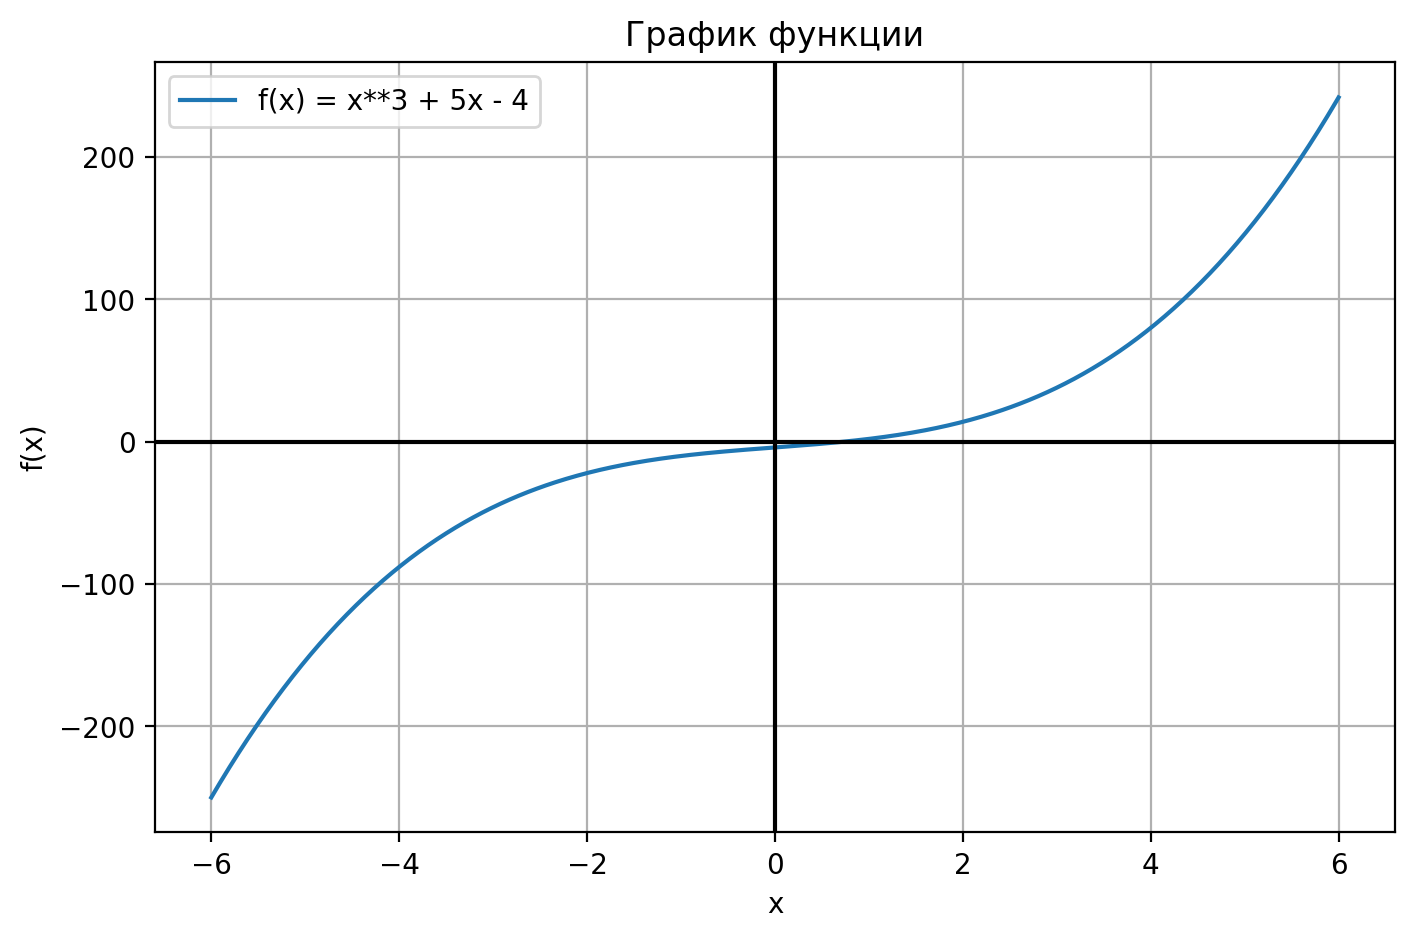

In [ ]:
x_vals_full = np.linspace(-6, 6, 500)
y_vals_full = f(x_vals_full)

plt.figure(figsize=(8, 5))
plt.plot(x_vals_full, y_vals_full, label="f(x) = x**3 + 5x - 4")

plt.axhline(0, color='black')
plt.axvline(0, color='black')

plt.title("График функции")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.legend()

In [ ]:
eps = 0.01
a, b = 0, 1

x_vals = np.linspace(0.25, 1.1, 400)
y_vals = f(x_vals)

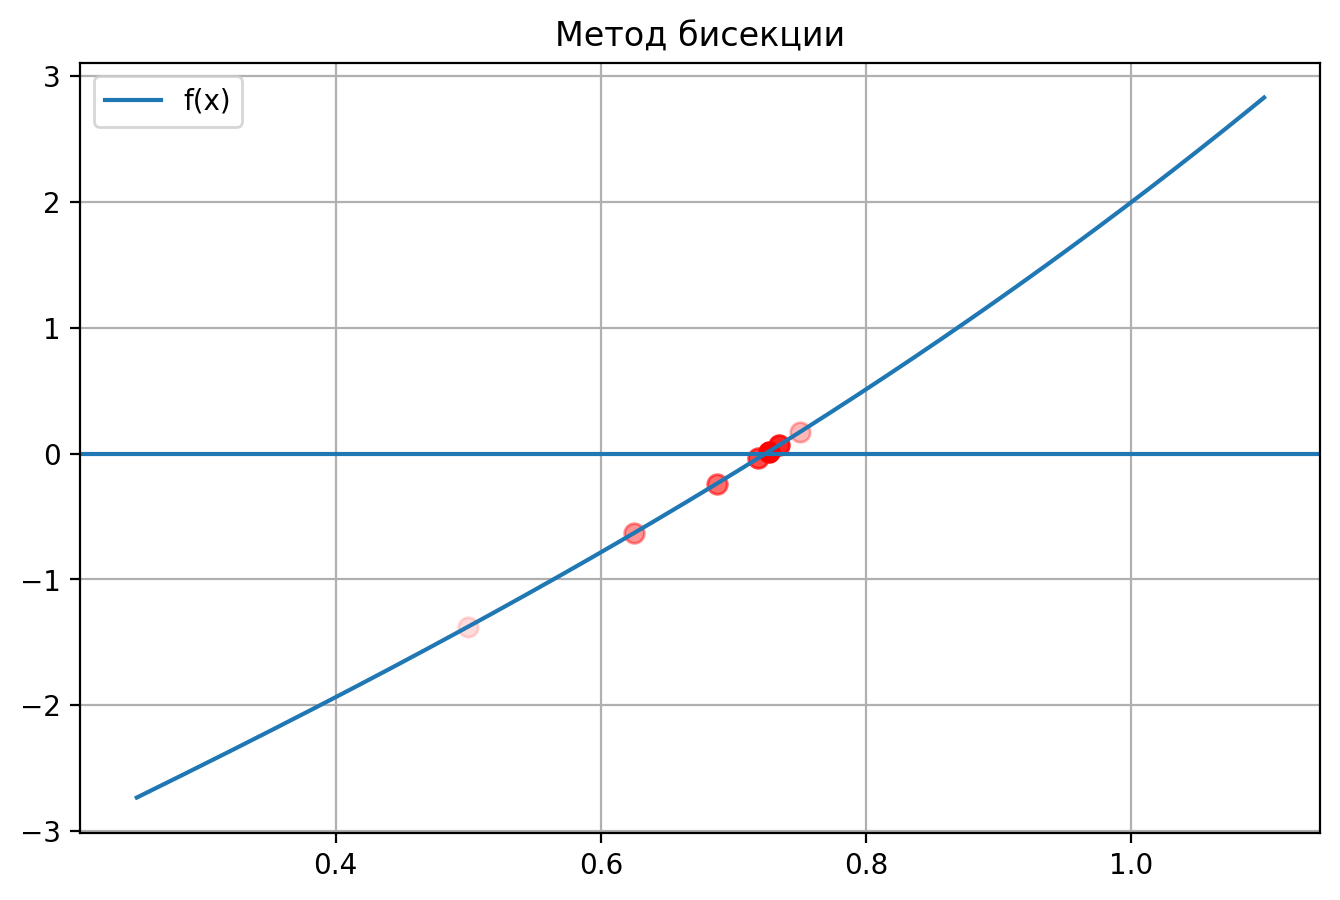

In [ ]:
def bisection_steps(a, b, eps):
    steps = []
    while abs(b - a) > eps:
        x = (a + b) / 2
        steps.append(x)
        if f(a) * f(x) < 0:
            b = x
        else:
            a = x
    return steps

def display_bisection_graph():
    bis_steps = bisection_steps(a, b, eps)

    plt.figure(figsize=(8, 5))
    plt.plot(x_vals, y_vals, label="f(x)")
    plt.axhline(0)

    num_steps = len(bis_steps)
    for i, x in enumerate(bis_steps):
        y = f(x)
        alpha_point = (i + 1) / num_steps
        plt.scatter(x, y, color='red', alpha=alpha_point, s=50)

    plt.title("Метод бисекции")
    plt.legend()
    plt.grid()
    plt.show()

display_bisection_graph()

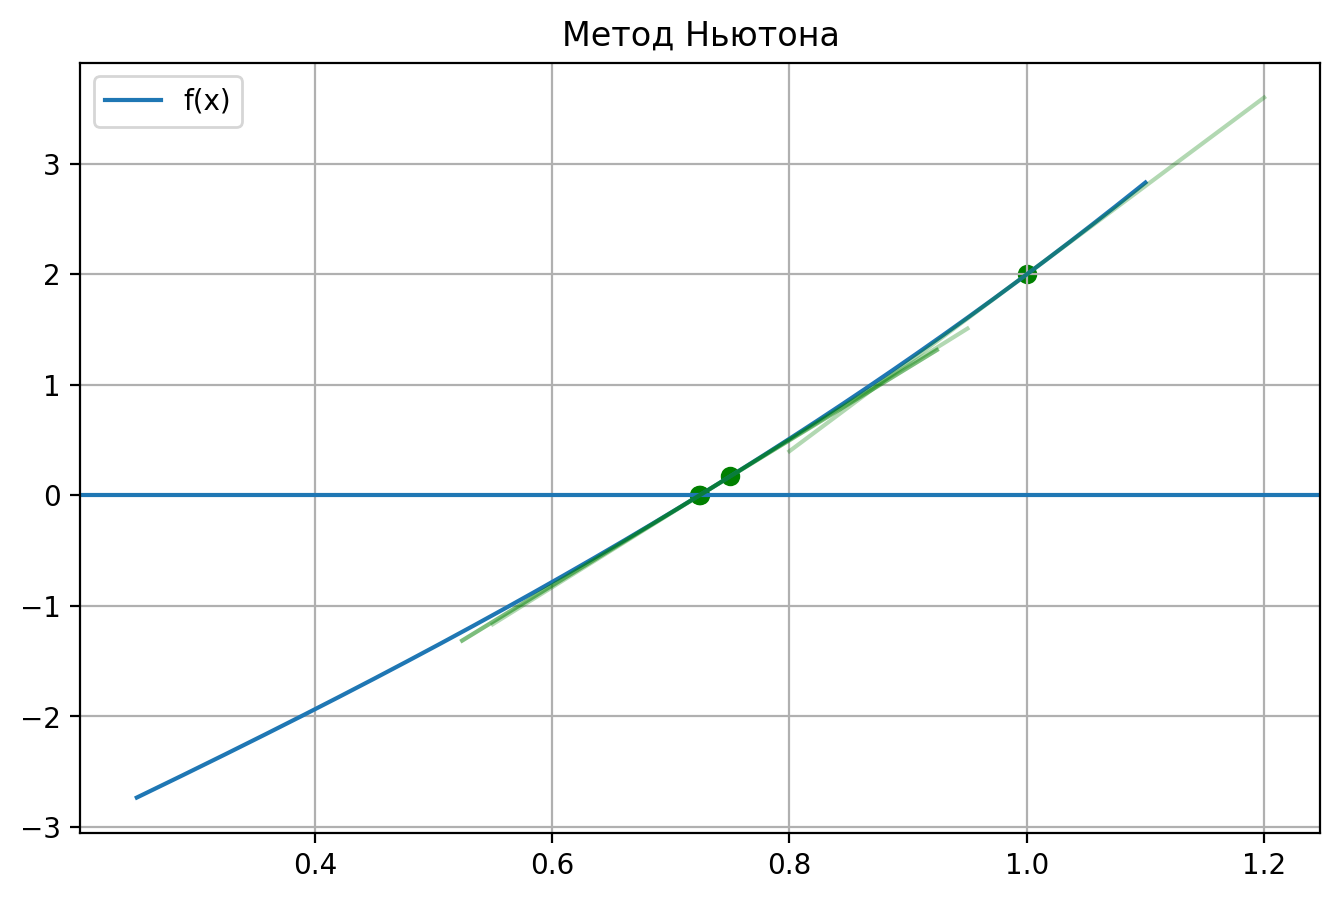

In [ ]:
def newton_steps(x0, eps):
    steps = [x0]
    x = x0
    while True:
        x_new = x - f(x) / df(x)
        steps.append(x_new)
        if abs(x_new - x) < eps:
            break
        x = x_new
    return steps

newt_steps = newton_steps(1, eps)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, label="f(x)")
plt.axhline(0)

for x in newt_steps:
    y = f(x)
    slope = df(x)

    plt.scatter(x, y, color='green')

    x_tan = np.linspace(x-0.2, x+0.2, 50)
    y_tan = y + slope*(x_tan - x)
    plt.plot(x_tan, y_tan, color='green', alpha=0.3)

plt.title("Метод Ньютона")
plt.legend()
plt.grid()
plt.show()

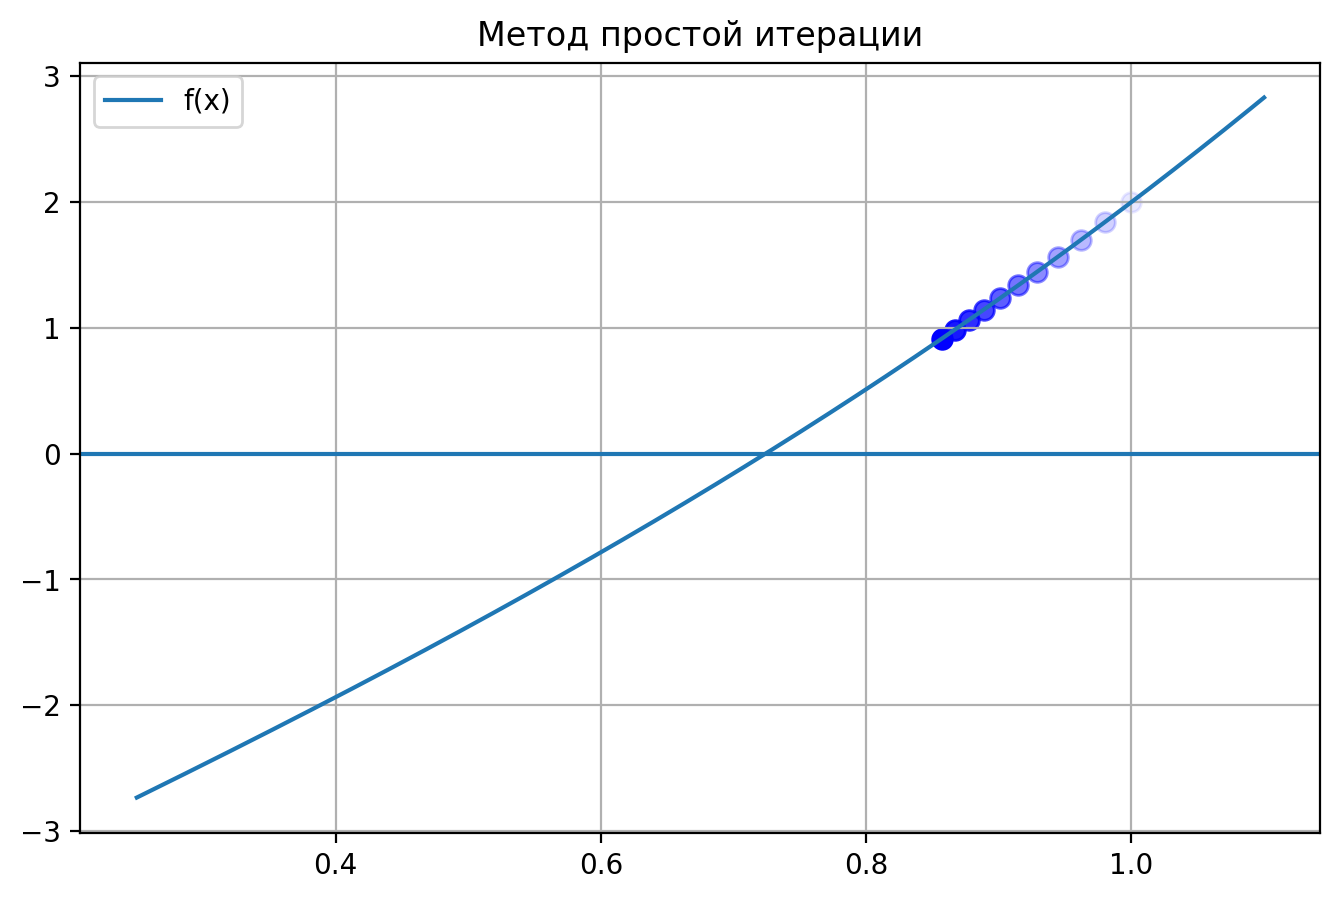

In [ ]:
def simple_iter_steps(x0, eps):
    M = 100
    steps = [x0]
    x = x0
    while True:
        x_new = x - f(x) / M
        steps.append(x_new)
        if abs(x_new - x) < eps:
            break
        x = x_new
    return steps

iter_steps = simple_iter_steps(1, eps)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, label="f(x)")
plt.axhline(0)

num_steps = len(iter_steps)
for i, x_iter in enumerate(iter_steps):
    y_iter = f(x_iter)
    alpha = (i + 1) / num_steps
    plt.scatter(x_iter, y_iter, color='blue', alpha=alpha, s=50)

plt.title("Метод простой итерации")
plt.legend()
plt.grid()
plt.show()

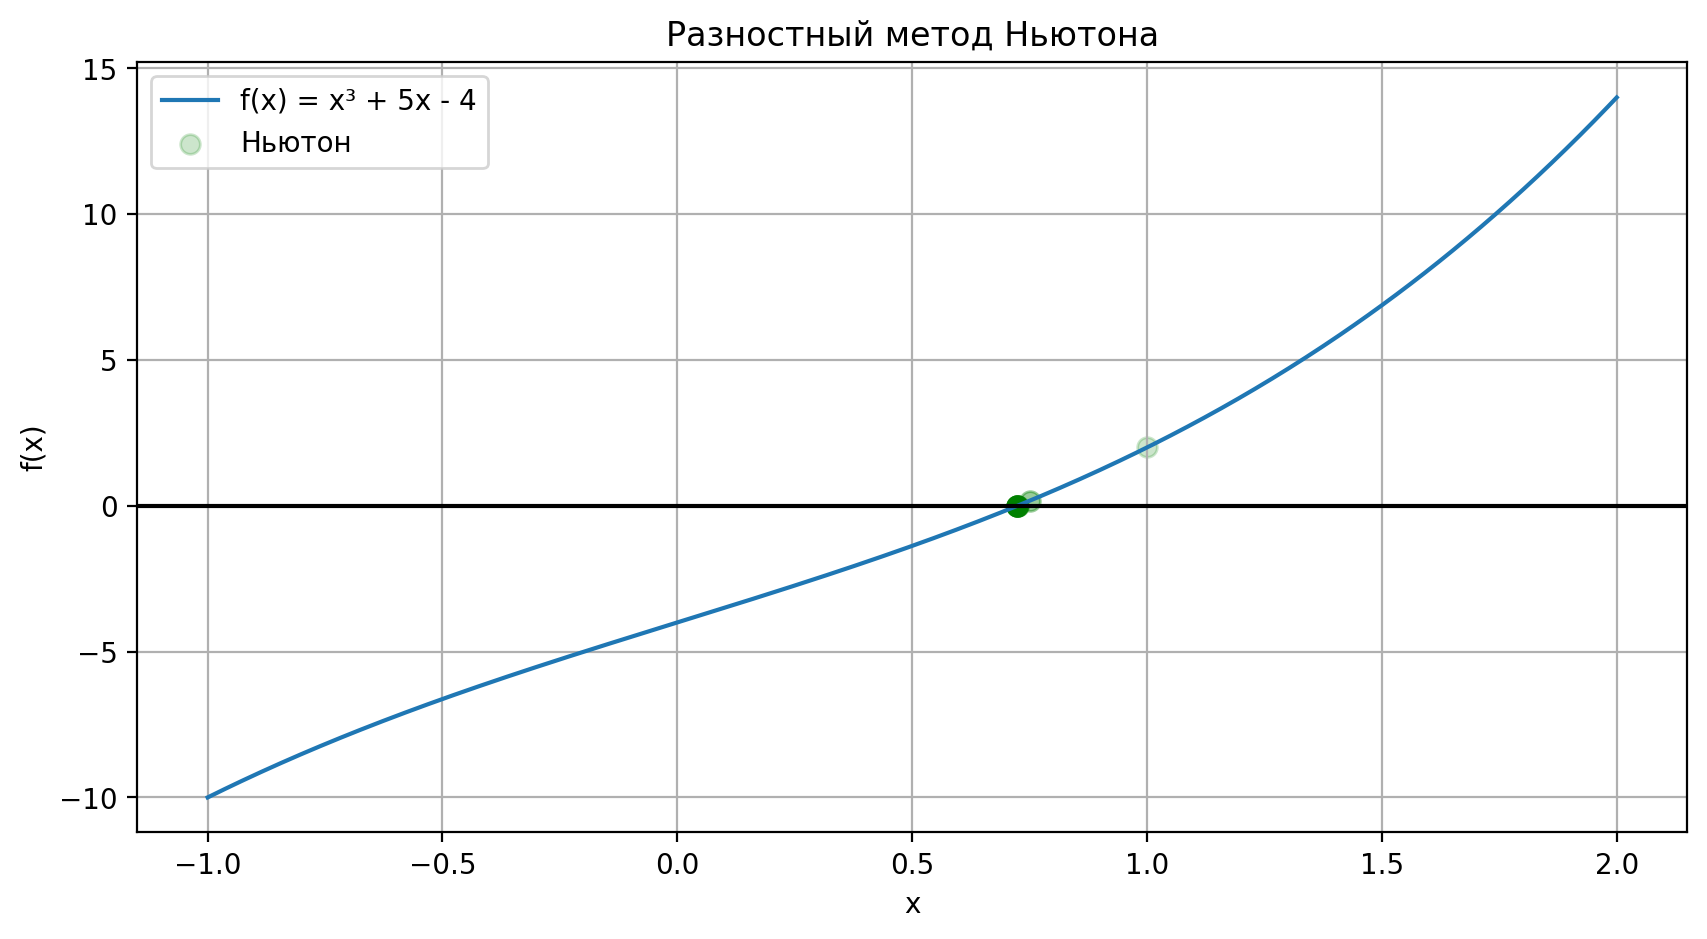

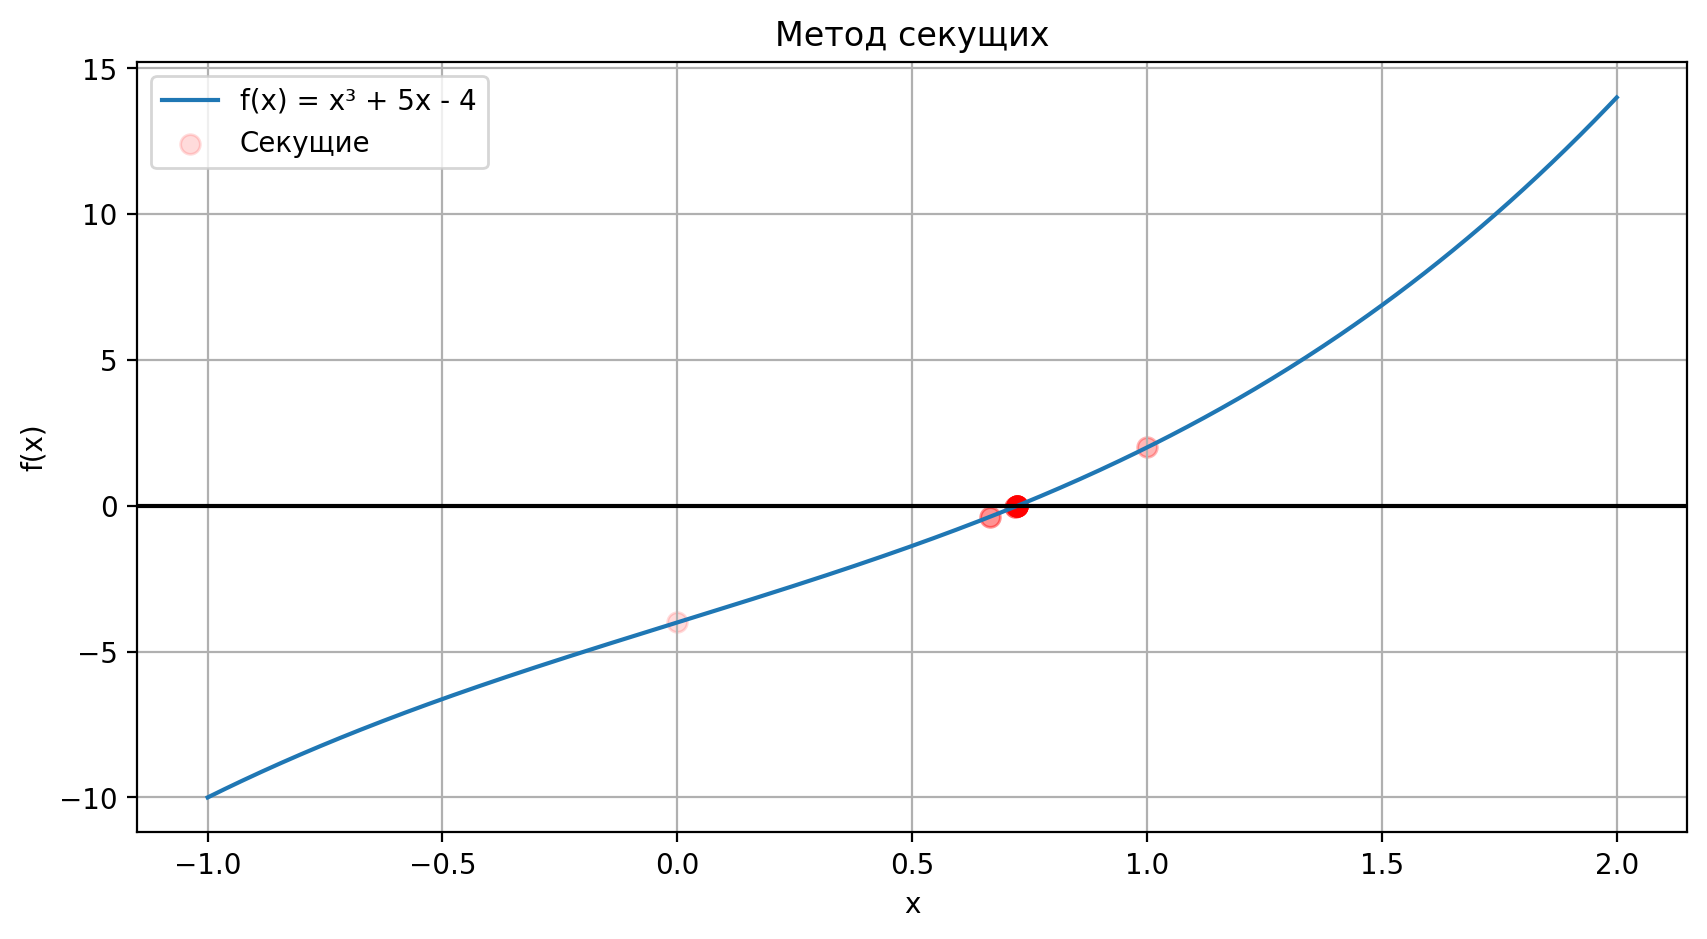

In [ ]:
def run_two_methods():
    import numpy as np
    import matplotlib.pyplot as plt

    eps = 1e-6
    h = 1e-5

    x = 1.0
    newton_diff_steps = [x]
    while True:
        f_x = f(x)
        f_diff = (f(x + h) - f_x) / h
        x_new = x - f_x / f_diff
        newton_diff_steps.append(x_new)
        if abs(x_new - x) < eps:
            break
        x = x_new

    x0 = 0.0
    x1 = 1.0
    secant_steps = [x0, x1]
    while True:
        f0 = f(x0)
        f1 = f(x1)
        x_new = x1 - f1 * (x1 - x0) / (f1 - f0)
        secant_steps.append(x_new)
        if abs(x_new - x1) < eps:
            break
        x0, x1 = x1, x_new

    x_vals = np.linspace(-1, 2, 500)
    y_vals = f(x_vals)

    plt.figure(figsize=(10, 5))
    plt.plot(x_vals, y_vals, label="f(x) = x³ + 5x - 4")
    plt.axhline(0, color='black')
    num_steps = len(newton_diff_steps)
    for i, x in enumerate(newton_diff_steps):
        y = f(x)
        alpha = (i + 1) / num_steps
        plt.scatter(x, y, color='green', alpha=alpha, s=50, label="Ньютон" if i==0 else "")
    plt.title("Разностный метод Ньютона")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.grid()
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(x_vals, y_vals, label="f(x) = x³ + 5x - 4")
    plt.axhline(0, color='black')
    num_steps_sec = len(secant_steps)
    for i, x in enumerate(secant_steps):
        y = f(x)
        alpha = (i + 1) / num_steps_sec
        plt.scatter(x, y, color='red', alpha=alpha, s=50, label="Секущие" if i==0 else "")
    plt.title("Метод секущих")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.grid()
    plt.legend()
    plt.show()

run_two_methods()